# Assignment 2: Evaluating the Impact of FOMC Communications on Asset Prices
FRE-GY 7871 A — NLP and the Investment Process, Fall 2026

**Pipeline:** collect documents -> score tone (word list + FinBERT) -> pull market
data -> regress market reactions on tone -> forecast the September FOMC meeting.


In [1]:
import os
for f in ['raw_fomc_docs.pkl', 'raw_speech_docs.pkl', 'fomc_documents_scored.csv',
          'fomc_documents.csv', 'fomc_market_reactions.csv']:
    path = f'../data/{f}'
    if os.path.exists(path):
        os.remove(path)
        print('deleted', path)
    else:
        print('not found (already clean):', path)

not found (already clean): ../data/raw_fomc_docs.pkl
not found (already clean): ../data/raw_speech_docs.pkl
not found (already clean): ../data/fomc_documents_scored.csv
not found (already clean): ../data/fomc_documents.csv
not found (already clean): ../data/fomc_market_reactions.csv


In [2]:
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    REPO_URL = 'https://github.com/aayush226/FRE-GY-7871A-Assignment2.git'
    REPO_DIR = '/content/FRE-GY-7871A-Assignment2'

    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL} {REPO_DIR}
    os.chdir(f'{REPO_DIR}/notebooks')

    !pip install -q -U pillow
    !pip install -q beautifulsoup4 yfinance fredapi pdfplumber tqdm transformers statsmodels

    import torch
    print('CUDA available:', torch.cuda.is_available())
    if not torch.cuda.is_available():
        print('WARNING: no GPU detected — check Runtime > Change runtime type > GPU')

sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import fomc_scraper
import speech_scraper
import market_data
import tone_scoring
import analysis

pd.set_option('display.max_columns', 50)


CUDA available: True


## Step 1: Collect documents
Statements + minutes (Feb 2018 - present) and Chair speeches/testimony
(Powell through May 21 2026, Warsh from May 22 2026).

In [3]:
import os
import pickle

FORCE_RESCRAPE = False  # set True only to re-hit federalreserve.gov

FOMC_CACHE = '../data/raw_fomc_docs.pkl'
SPEECH_CACHE = '../data/raw_speech_docs.pkl'

YEARS = list(range(2018, 2027))  # 2018..2026

if not FORCE_RESCRAPE and os.path.exists(FOMC_CACHE):
    with open(FOMC_CACHE, 'rb') as f:
        fomc_docs, meeting_dates = pickle.load(f)
    print(f"Loaded {len(fomc_docs)} statement/minutes/press-conference documents from cache")
else:
    # returns (docs, meeting_dates). include_press_conferences=True also
    # fetches and extracts text from every FOMC press conference PDF transcript
    # — a 'skipped' message for a given date is expected for meetings that had
    # no press conference, same as the minutes 404s.
    fomc_docs, meeting_dates = fomc_scraper.collect_all(YEARS, sleep_between=1.0, include_press_conferences=True)
    print(f"Collected {len(fomc_docs)} statement/minutes/press-conference documents")
    os.makedirs('../data', exist_ok=True)
    with open(FOMC_CACHE, 'wb') as f:
        pickle.dump((fomc_docs, meeting_dates), f)


Loaded 209 statement/minutes/press-conference documents from cache


In [4]:
if not FORCE_RESCRAPE and os.path.exists(SPEECH_CACHE):
    with open(SPEECH_CACHE, 'rb') as f:
        speech_docs = pickle.load(f)
    print(f"Loaded {len(speech_docs)} speech/testimony documents from cache")
else:
    speech_docs = speech_scraper.collect_all_speeches(YEARS, sleep_between=1.0)
    print(f"Collected {len(speech_docs)} speech/testimony documents")
    with open(SPEECH_CACHE, 'wb') as f:
        pickle.dump(speech_docs, f)


Loaded 106 speech/testimony documents from cache


In [5]:
# Combine into one DataFrame with a common schema
rows = []
for d in fomc_docs:
    rows.append({
        'doc_type': d.doc_type,
        'speaker': None,
        'meeting_date': d.meeting_date,
        'release_date': d.release_date,
        'release_time': d.release_time,
        'url': d.url,
        'text': d.text,
    })
for d in speech_docs:
    rows.append({
        'doc_type': d.doc_type,
        'speaker': d.speaker,
        'meeting_date': None,
        'release_date': d.release_date,
        'release_time': d.release_time,
        'url': d.url,
        'text': d.text,
    })

docs_df = pd.DataFrame(rows)

def _infer_chair(row):
    # Prefer meeting_date (who chaired the meeting) for statements/minutes/
    # press conferences; fall back to release_date for speeches, which have
    # no meeting_date.
    meeting_date = row['meeting_date']
    release_date = row['release_date']
    d = meeting_date if pd.notna(meeting_date) and meeting_date else release_date
    if pd.isna(d) or not d:
        return 'powell'  # no usable date; default (shouldn't normally happen)
    return 'warsh' if str(d) >= '2026-05-22' else 'powell'

docs_df['chair'] = docs_df.apply(_infer_chair, axis=1)
docs_df.to_csv('../data/fomc_documents.csv', index=False)
docs_df.shape


(315, 8)

### Table 1: Documents collected, by type and by Chair

In [6]:
table1 = docs_df.groupby(['chair', 'doc_type']).size().unstack(fill_value=0)
table1


doc_type,minutes,press_conference,speech,statement,testimony
chair,,,,,
powell,66,64,78,73,26
warsh,2,2,1,2,1


## Step 2: Trend analysis — score tone
Word list + FinBERT (sentiment) + FinBERT factor similarity, per the
"Parsing the Fed" methodology (no dependence on the 5-year-delayed
alternative statements, which aren't public past Dec 2014).

In [7]:
!pip install -q -U pillow

In [8]:
SCORE_CHECKPOINT = '../data/fomc_documents_scored.csv'

scored_df = tone_scoring.score_documents(docs_df, text_col='text', checkpoint_path=SCORE_CHECKPOINT)
scored_df[['release_date', 'doc_type', 'chair', 'wordlist_score', 'finbert_score', 'rate_factor', 'inflation_factor']].head()


Resuming from checkpoint: 315 documents already scored


Scoring documents:   0%|          | 0/315 [00:00<?, ?it/s]

,release_date,doc_type,chair,wordlist_score,finbert_score,rate_factor,inflation_factor
0,2018-03-21,statement,powell,0.451842,0.091580,0.558822,0.441033
1,2018-04-11,minutes,powell,0.199927,0.031953,0.482559,0.411495
2,2018-05-02,statement,powell,-0.170342,0.136944,0.568637,0.446133
3,2018-05-23,minutes,powell,0.121410,0.082907,0.492144,0.405419
4,2018-06-13,statement,powell,0.712802,0.159756,0.556997,0.437495


### Figure 1: Hawkish/dovish tone over time by document type
Warsh's term start (2026-05-22) marked with a vertical line.

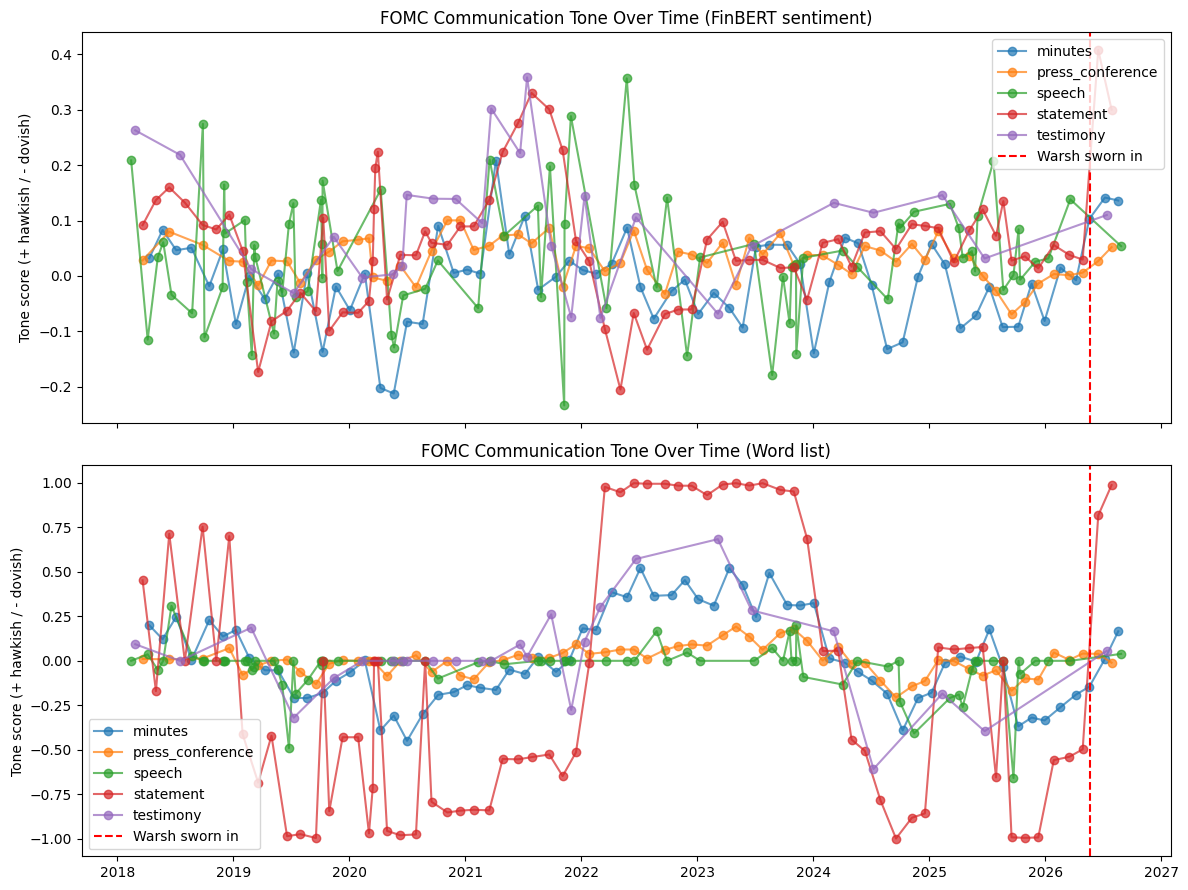

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

for doc_type, grp in scored_df.dropna(subset=['release_date']).groupby('doc_type'):
    grp = grp.sort_values('release_date')
    axes[0].plot(pd.to_datetime(grp['release_date']), grp['finbert_score'], marker='o', label=doc_type, alpha=0.7)
    axes[1].plot(pd.to_datetime(grp['release_date']), grp['wordlist_score'], marker='o', label=doc_type, alpha=0.7)

for ax, title in zip(axes, ['FinBERT sentiment', 'Word list']):
    ax.axvline(pd.Timestamp('2026-05-22'), color='red', linestyle='--', label='Warsh sworn in')
    ax.set_title(f'FOMC Communication Tone Over Time ({title})')
    ax.set_ylabel('Tone score (+ hawkish / - dovish)')
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figure1_tone_over_time.png', dpi=150)
plt.show()


### Powell vs. Warsh comparison

In [10]:
comparison = scored_df.groupby('chair')[['wordlist_score', 'finbert_score', 'rate_factor', 'inflation_factor']].mean()
comparison


,wordlist_score,finbert_score,rate_factor,inflation_factor
chair,,,,
powell,-0.035294,0.032456,0.540089,0.426120
warsh,0.262813,0.153483,0.545390,0.425526


## Step 3: Validate market reactions
Pull the four indicators + 3-month bill control, compute one-day changes
around each release, and regress on tone scores.

In [11]:
FRED_API_KEY = None  # optional: paste key from https://fred.stlouisfed.org/docs/api/api_key.html
# If left as None, market_data.py falls back to FRED's no-auth CSV endpoint.

panel = market_data.build_indicator_panel(start='2018-01-01', end='2026-09-14', fred_api_key=FRED_API_KEY)
panel.to_csv('../data/market_indicator_panel.csv')
panel.tail()


,dxy,t10y2y,dgs1,growth_value_pct_spread,dgs3mo
2026-09-08,98.839996,0.41,4.15,0.005120,3.94
2026-09-09,98.769997,0.40,4.17,0.005683,3.95
2026-09-10,99.089996,0.39,4.28,-0.002460,4.00
2026-09-11,99.120003,0.33,4.35,0.004542,4.07
2026-09-14,99.459999,0.32,4.37,-0.007168,4.11


In [12]:
# Compute one-day changes for every scored document's release date. Passing
# release_time lets after-hours events (mainly speeches/testimony, which
# unlike statements/minutes/press conferences aren't always 2-2:30pm ET) get
# credited to the next trading day instead of the same day.
change_rows = []
for _, row in scored_df.dropna(subset=['release_date']).iterrows():
    changes = market_data.one_day_change(panel, row['release_date'], release_time=row.get('release_time'))
    if not changes:
        continue
    change_rows.append({**row.to_dict(), **changes})

market_df = pd.DataFrame(change_rows)
market_df.to_csv('../data/fomc_market_reactions.csv', index=False)
market_df.shape


(315, 17)

### Table 2: One-day changes after each Warsh-era release, next to tone scores

In [13]:
table2 = market_df[market_df['chair'] == 'warsh'][
    ['release_date', 'doc_type', 'wordlist_score', 'finbert_score', 'rate_factor', 'inflation_factor',
     'd_dxy', 'd_t10y2y', 'd_dgs1', 'd_growth_value']
].sort_values('release_date')
table2


,release_date,doc_type,wordlist_score,finbert_score,rate_factor,inflation_factor,d_dxy,d_t10y2y,d_dgs1,d_growth_value
139,2026-06-17,statement,0.816590,0.407555,0.554867,0.414818,0.549995,-0.09,0.14,-0.002578
207,2026-06-17,press_conference,0.039207,0.026864,0.580043,0.439708,0.549995,-0.09,0.14,-0.002578
140,2026-07-08,minutes,0.010528,0.141461,0.489092,0.409853,-0.089996,-0.01,0.00,0.015063
314,2026-07-14,testimony,0.055995,0.109986,0.564977,0.418670,-0.339996,0.04,-0.10,0.014307
141,2026-07-29,statement,0.986265,0.300175,0.569244,0.423173,-0.579994,0.10,-0.05,-0.009662
208,2026-07-29,press_conference,-0.010700,0.051948,0.571892,0.444928,-0.579994,0.10,-0.05,-0.009662
142,2026-08-19,minutes,0.165594,0.136146,0.459284,0.396573,-0.820000,-0.06,0.01,-0.008418
287,2026-08-28,speech,0.039025,0.053730,0.573722,0.456485,0.539993,-0.08,0.11,-0.002082


### Table 3: Regressions — indicator change ~ tone score + 3mo bill control

In [14]:
table3 = analysis.run_regressions(market_df, control_col='d_dgs3mo')
table3.sort_values(['target', 'tone_score'])


,target,tone_score,n_obs,coef_tone,t_stat_tone,p_value_tone,coef_control,t_stat_control,r_squared
9,d_dgs1,finbert_score,311,-0.015467,-0.628416,0.530197,0.962191,12.304010,3.295441e-01
11,d_dgs1,inflation_factor,311,0.068166,0.607034,0.544275,0.965617,12.266409,3.294867e-01
10,d_dgs1,rate_factor,311,-0.055282,-0.821414,0.412046,0.950430,12.052789,3.301519e-01
8,d_dgs1,wordlist_score,311,-0.006952,-1.126721,0.260738,0.961319,12.324893,3.314401e-01
1,d_dxy,finbert_score,311,0.137855,0.552955,0.580696,4.277356,5.399837,8.837681e-02
3,d_dxy,inflation_factor,311,-1.269712,-1.118036,0.264423,4.188543,5.261122,9.116031e-02
2,d_dxy,rate_factor,311,-0.559243,-0.820472,0.412582,4.207380,5.268181,8.946192e-02
0,d_dxy,wordlist_score,311,-0.132284,-2.127856,0.034143,4.332702,5.513572,1.006922e-01
13,d_growth_value,finbert_score,311,-0.008630,-1.183016,0.237715,0.001242,0.053608,4.523593e-03
15,d_growth_value,inflation_factor,311,0.012160,0.364632,0.715637,0.000876,0.037475,4.317174e-04


## Comparison with the readings

- Doh, Kim, Yang (2021) and Doh, Song, Yang (2020/2023) find that qualitative tone has "as much of an effect on financial market conditions as quantitative information about the target policy rate." Our results only partly support this. Across 16 tone-score/indicator regressions (n=311), just one is significant: word-list score against the one-day change in DXY (coefficient = -0.132, t = -2.13, p = 0.034). Every other tone measure — FinBERT sentiment, rate factor, inflation factor — is insignificant against all four indicators, and even where R² is largest (DGS1, ≈0.33), that comes almost entirely from the 3-month bill control (t ≈ 12.0–12.3), not tone (t < 1.2 throughout). So tone, as we measure it, mostly does not explain next-day asset-price moves here — a much weaker result than the KC Fed papers report.

- The one significant relationship also runs opposite to theory: more hawkish word-list tone is associated with the dollar falling, not rising. This survived expanding the lexicon from 24 to 68 phrases and adding testimony to the sample, so it isn't a thin-word-list artifact — plausibly a "buy the rumor, sell the news" dynamic, where hawkish language is already priced in before release.

- We attribute the gap mainly to methodology, not text-scoring quality. Doh, Song, Yang decompose tone into expected vs. surprise components using intraday bond futures and narrow 10–90 minute windows; our word-list/FinBERT scores mix both together over full-day changes, letting macro noise swamp the FOMC-specific signal. Their fine-tuned USE also distinguishes numeric magnitude (25bp vs. 50bp); ours cannot.

- Against "Parsing the Fed" specifically — which also avoids the 5-year-delayed alternative statements — our results are consistent, not an outlier: their appendix reports R² from under 1% to ~24% across methods, and ours (mostly <10%, aside from the control-dominated DGS1 regressions) sits in that same range. This suggests non-alternative-statement methods consistently produce weaker, noisier signal than the surprise-decomposition approach, across two independent projects.


## Step 4: Forecast — September 2026 FOMC meeting
Use the trend from Step 2 and the regression coefficients from Step 3 to
form the required forecast.

In [7]:
forecast = {
    'rate_decision': {'cut': 1, 'hold': 7, 'hike': 92},
    'statement_more_hawkish_than_prev': 70,
    'market_reaction': {
    'dxy': {'p_rise': 25, 'expected_change': '-0.45% (about -0.45 index points)'},
    't10y2y': {'p_rise': 35, 'expected_change': '-0.06 pp (about -6 bps, curve flattens on a hike)'},
    'dgs1': {'p_rise': 75, 'expected_change': '+0.08 pp (about +8 bps)'},
    'growth_value': {'p_rise': 30, 'expected_change': '-0.30% (growth underperforms value)'},
    },
    'recommendation': (
        "Small, tactically-sized short-DXY tilt around the announcement. "
        "The ~93% hike probability is already priced in (CME FedWatch), so "
        "betting on hike-vs-hold offers little edge. The one relationship "
        "this analysis found that is NOT already priced in is the "
        "significant, negative wordlist_score -> d_dxy relationship "
        "(coef=-0.132, p=0.034, n=311): more hawkish statement language is "
        "associated with the dollar falling, not rising, the next day -- "
        "consistent with a 'buy the rumor, sell the news' pattern. Size "
        "small given the modest effect size (R^2 ~ 10%)."
    ),
    'invalidation': (
        "If DXY rises more than ~0.3-0.5% the day after a statement that "
        "scores clearly hawkish (wordlist_score > 0.5), that directly "
        "contradicts the estimated relationship this recommendation is "
        "based on. Separately, if the Fed holds instead of hiking (the "
        "~7% tail case -- would be the most dovish surprise on record per "
        "Deutsche Bank), that is a different regime this tone-based thesis "
        "was not built to capture."
    ),
}
forecast

{'rate_decision': {'cut': 1, 'hold': 7, 'hike': 92},
 'statement_more_hawkish_than_prev': 70,
 'market_reaction': {'dxy': {'p_rise': 25,
   'expected_change': '-0.45% (about -0.45 index points)'},
  't10y2y': {'p_rise': 35,
   'expected_change': '-0.06 pp (about -6 bps, curve flattens on a hike)'},
  'dgs1': {'p_rise': 75, 'expected_change': '+0.08 pp (about +8 bps)'},
  'growth_value': {'p_rise': 30,
   'expected_change': '-0.30% (growth underperforms value)'}},
 'recommendation': "Small, tactically-sized short-DXY tilt around the announcement. The ~93% hike probability is already priced in (CME FedWatch), so betting on hike-vs-hold offers little edge. The one relationship this analysis found that is NOT already priced in is the significant, negative wordlist_score -> d_dxy relationship (coef=-0.132, p=0.034, n=311): more hawkish statement language is associated with the dollar falling, not rising, the next day -- consistent with a 'buy the rumor, sell the news' pattern. Size small gi

### Final write-up

**Rate decision:** P(cut) = 1%, P(hold) = 7%, P(hike) = 92%

**Statement tone:** P(more hawkish than previous statement) = 70%

**Market reaction:**
| Indicator | P(rises) | Expected change |
|---|---|---|
| DXY | 25% | -0.45% |
| 10s2s | 35% | -6 bps |
| 1yr Treasury | 75% | +8 bps |
| Growth-Value | 30% | -0.30% |

**Recommendation:** The Fed almost certainly hikes tomorrow (~92% priced in), and Warsh's language should stay noticeably more hawkish than Powell's ever was — but that hawkish tone has historically coincided with the dollar weakening, not strengthening, so the trade is a small short-DXY position, not a bet on the hike itself. That ~92% hike probability is already priced into markets (CME FedWatch), so the hike-vs-hold decision itself offers little edge. The one relationship this analysis found that is *not* already priced in is the statistically significant, negative relationship between word-list hawkishness and DXY's one-day change (coefficient = -0.132, t = -2.13, p = 0.034, n = 311): more hawkish language is associated with the dollar falling, not rising -- consistent with a "buy the rumor, sell the news" pattern rather than the standard hawkish-tone-strengthens-the-dollar prior. Position sized small given the modest effect size (R² ≈ 10%).

**What would prove this wrong:** If DXY rises meaningfully (>0.3-0.5%) following a statement that scores clearly hawkish (word-list score > 0.5), that directly contradicts the relationship this recommendation is based on. Separately, if the Fed holds rather than hikes (the ~7% tail scenario -- flagged by Deutsche Bank as potentially "the biggest dovish surprise on record"), that is a different regime this tone-based thesis was not designed to address.